# 🏦 Loan Data Analytics: Statistical & Mathematical Profiling

### 🛠️ Setup & Data Load

In [99]:
# Import All Library
import numpy as np
import pandas as pd
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import norm

In [100]:
# Read csv file
df = pd.read_csv('loan_applications.csv')

### 🔍 Preview Dataset

In [101]:
df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term (months),Default_Status
0,CUST_0001,59,59751,27300,716,12,No
1,CUST_0002,49,43143,9000,604,24,No
2,CUST_0003,35,51774,175700,796,36,No
3,CUST_0004,63,50293,10900,590,48,Yes
4,CUST_0005,28,35008,18900,401,60,Yes


> 💡 **Key Insight:** This code displays the first 5 rows of the dataset to verify column structures and data formatting at a glance.

### 📊 Statistical Summary

In [102]:
df.describe()

,Age,Income,Loan_Amount,Credit_Score,Loan_Term (months)
count,500.00000,500.000000,500.000000,500.000000,500.000000
mean,43.53600,47637.086000,88908.600000,580.150000,38.184000
std,13.02613,7560.537871,48817.880299,159.310134,15.045627
min,21.00000,26158.000000,5800.000000,301.000000,12.000000
25%,32.00000,42737.500000,46825.000000,441.500000,24.000000
50%,45.00000,47670.000000,88700.000000,581.000000,36.000000
75%,54.25000,53198.250000,126300.000000,720.250000,48.000000
max,65.00000,66349.000000,214300.000000,849.000000,60.000000


> 💡 **Key Insight:** This code calculates essential summary statistics like mean, standard deviation, and quartiles for all numerical variables to understand data distribution instantly.

### 📐 Income: Central Tendency

In [103]:
# Mean (Average Income)
income_mean = df['Income'].mean()

# Median (Middle value of Income)
income_median = df['Income'].median()

# Mode (Most frequent Income) 
income_mode = stats.mode(df['Income'])[0]


In [104]:
print("--- Part B: Step 1 - Central Tendency Results ---\n")
print(f"Mean of Income   : {income_mean:.2f}")
print(f"Median of Income : {income_median:.2f}")
print(f"Mode of Income   : {income_mode}")

--- Part B: Step 1 - Central Tendency Results ---

Mean of Income   : 47637.09
Median of Income : 47670.00
Mode of Income   : 42013


> 💡 **Key Insight:** This code calculates the mean, median, and mode of customer income to establish the baseline earning profile and identify the most common income bracket.

### 📊 Visualizing Central Tendency

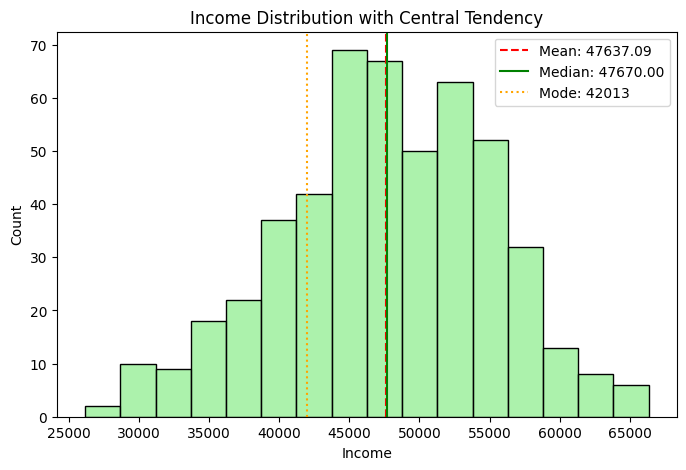

In [105]:
# Optional Visual
plt.figure(figsize=(8, 5))
sns.histplot(df['Income'], color='lightgreen', kde=False)

# Vertical lines for Mean, Median, and Mode
plt.axvline(income_mean, color='red', linestyle='--', label=f'Mean: {income_mean:.2f}')
plt.axvline(income_median, color='green', linestyle='-', label=f'Median: {income_median:.2f}')
plt.axvline(income_mode, color='orange', linestyle=':', label=f'Mode: {income_mode}')

plt.title("Income Distribution with Central Tendency")
plt.xlabel("Income")
plt.ylabel("Count")
plt.legend()
plt.show()

> 💡 **Key Insight:** This plot maps the mean, median, and mode directly onto the distribution histogram to visually evaluate how symmetrical or skewed customer earnings are.

### 📐 Loan Amount: Dispersion Metrics

In [106]:
# Range
loan_min = df['Loan_Amount'].min()
loan_max = df['Loan_Amount'].max()
loan_range = loan_max - loan_min

# Variance 
loan_variance = df['Loan_Amount'].var()

# Standard Deviation 
loan_std_dev = df['Loan_Amount'].std()

In [107]:
print("--- Part B: Step 1 - Dispersion Results (Loan_Amount) ---\n")
print(f"Range of Loan Amount              : {loan_range}")
print(f"Variance of Loan Amount           : {loan_variance:.2f}")
print(f"Standard Deviation of Loan Amount : {loan_std_dev:.2f}")

--- Part B: Step 1 - Dispersion Results (Loan_Amount) ---

Range of Loan Amount              : 208500
Variance of Loan Amount           : 2383185436.91
Standard Deviation of Loan Amount : 48817.88


> 💡 **Key Insight:** This code computes the range, variance, and standard deviation of requested loan amounts to track the overall spread and variability in borrowing patterns.

### 🎲 Baseline Probability of Default

In [108]:
# Total applications
total_applications = len(df)

# Total defaults "Yes"
total_defaults = (df['Default_Status'] == 'Yes').sum()

# Probability calculate : (Defaulted / Total)
prob_default = total_defaults / total_applications

In [109]:
print("--- Part B: Step 2 - Probability Results --- \n")
print(f"Total Applications     : {total_applications}")
print(f"Total Defaults (Yes)   : {total_defaults}")
print(f"Probability of Default : {prob_default:.4f} (yaani {prob_default * 100:.2f}%)")

--- Part B: Step 2 - Probability Results --- 

Total Applications     : 500
Total Defaults (Yes)   : 220
Probability of Default : 0.4400 (yaani 44.00%)


> 💡 **Key Insight:** This code calculates the baseline risk by determining the overall mathematical probability of an applicant defaulting on their loan across the entire portfolio.

### 📊 Credit Score: Contingency Table

In [110]:
bins = [0, 600, 700, 850]
labels = ['< 600', '600-700', '> 700']
df['Credit_Score_Range'] = pd.cut(df['Credit_Score'], bins=bins, labels=labels)

# Create Contingency table 
contingency_table = pd.crosstab(df['Default_Status'], df['Credit_Score_Range'])

# Display Table
print("--- Contingency Table (Default Status vs Credit Score Range) ---")
display(contingency_table)

--- Contingency Table (Default Status vs Credit Score Range) ---


Credit_Score_Range,< 600,600-700,> 700
Default_Status,,,
No,90,58,132
Yes,176,29,15


> 💡 **Key Insight:** This code categorizes credit scores into specific risk brackets and builds a contingency cross-tabulation table to cross-reference default patterns across different credit scores.

### 🎲 Conditional Probability Analysis

In [111]:
# Filter
low_score_df = df[df['Credit_Score'] < 600]

# Total "Yes"
total_low_score = len(low_score_df)

# Defaults
defaults_low_score = (low_score_df['Default_Status'] == 'Yes').sum()

# Probability
p_default_given_low_score = defaults_low_score / total_low_score

# Result
print(f"P(Default | Credit_Score < 600) : {p_default_given_low_score:.4f} ({p_default_given_low_score * 100:.2f}%)")

P(Default | Credit_Score < 600) : 0.6617 (66.17%)


> 💡 **Key Insight:** This code calculates the conditional probability of a loan default specifically given that the applicant's credit score is below 600, isolating the high-risk target group.


### 📊 Credit Score: Distribution Plot

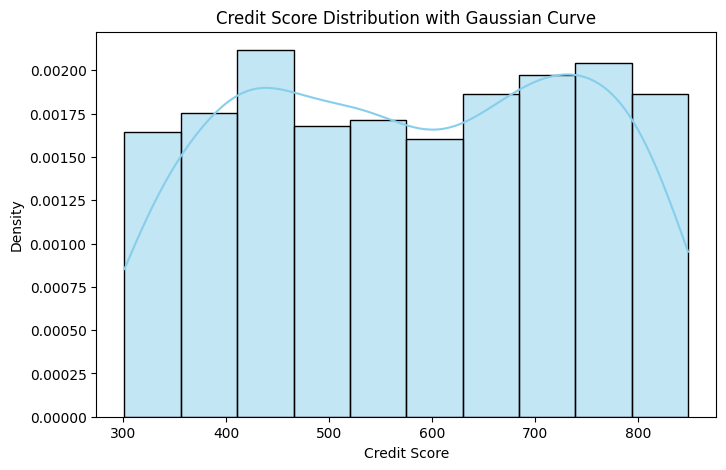

In [112]:
# --- Part B: Step 3 - Histogram with Gaussian Curve ---
plt.figure(figsize=(8, 5))
sns.histplot(df['Credit_Score'], kde=True, stat="density", color="skyblue")
plt.title("Credit Score Distribution with Gaussian Curve")
plt.xlabel("Credit Score")
plt.ylabel("Density")
plt.show()

> 💡 **Key Insight:** This code plots a histogram combined with a continuous Gaussian curve (KDE) to visually analyze how normally distributed the customer credit scores are.

### 📐 Loan Amount: Distribution Shape

In [113]:
# Skewness
loan_skew = df['Loan_Amount'].skew()

# Kurtosis
loan_kurt = df['Loan_Amount'].kurt()

# Results
print(f"Skewness of Loan Amount : {loan_skew:.4f}")
print(f"Kurtosis of Loan Amount : {loan_kurt:.4f}")

Skewness of Loan Amount : 0.1777
Kurtosis of Loan Amount : -0.8890


> 💡 **Key Insight:** This code calculates the skewness and kurtosis of the loan amounts to measure the asymmetry and peakness of the data distribution shape.

### 📊 Income: Q-Q Plot Analysis

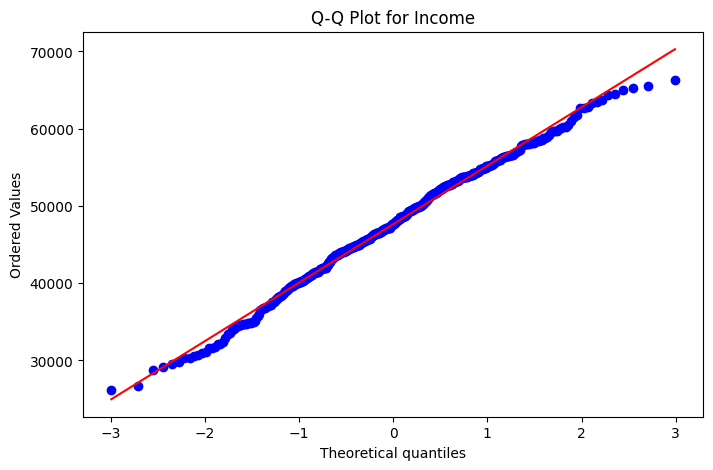

In [114]:
# --- Part B: Step 3 - Q-Q Plot for Income ---
plt.figure(figsize=(8,5))
stats.probplot(df['Income'], dist="norm", plot=plt)
plt.title("Q-Q Plot for Income")
plt.show()

> 💡 **Key Insight:** This code generates a Quantile-Quantile plot to visually compare the distribution of customer income against a theoretical normal distribution reference line.

### 📐 Vector Space Metrics

In [115]:
# Vectors
vectors = df[['Income', 'Loan_Amount']].head(5).to_numpy()
v1, v2 = vectors[0], vectors[1]

# Dot-Product
dot_product = np.dot(v1, v2)

# Norm-2
norm_v1 = norm(v1)
norm_v2 = norm(v2)

# Angle
cosine_theta = dot_product / (norm_v1 * norm_v2)
angle_radians = np.arccos(np.clip(cosine_theta, -1.0, 1.0))
angle_degrees = np.degrees(angle_radians)

In [116]:
# Results
print("--- Linear Algebra Results (First 2 Customers) ---\n")
print(f"Dot Product      : {dot_product:.2f}")
print(f"Norm 2 (Cust 1)  : {norm_v1:.2f}")
print(f"Norm 2 (Cust 2)  : {norm_v2:.2f}")
print(f"Angle (Degrees)  : {angle_degrees:.2f}°")

--- Linear Algebra Results (First 2 Customers) ---

Dot Product      : 2823537393.00
Norm 2 (Cust 1)  : 65692.25
Norm 2 (Cust 2)  : 44071.74
Angle (Degrees)  : 12.77°


> 💡 **Key Insight:** This code treats customer financial profiles as mathematical vectors to compute their magnitude, dot product, and directional angle to check directional similarity.

### 📐 Vector Magnitude (Norm-2)

In [117]:
# Vector
vectors = df[['Income', 'Loan_Amount']].head(5).to_numpy()
customer_vector = vectors[0]

# Norm-2
customer_norm = norm(customer_vector)

# Result
print(f"Norm 2 of Customer 1 vector : {customer_norm:.2f}")

Norm 2 of Customer 1 vector : 65692.25


> 💡 **Key Insight:** This code calculates the Euclidean distance (Norm-2 magnitude) for a single customer vector to evaluate the absolute financial scale of that specific applicant.

### 📐 Vector Directional Angle

In [118]:
# Vectors
vectors = df[['Income', 'Loan_Amount']].head(5).to_numpy()
v1, v2 = vectors[0], vectors[1]

# Cosine
cosine_theta = np.dot(v1, v2) / (norm(v1) * norm(v2))

# Angle
angle_degrees = np.degrees(np.arccos(np.clip(cosine_theta, -1.0, 1.0)))

# Result
print(f"Angle between vectors (Degrees) : {angle_degrees:.2f}°")

Angle between vectors (Degrees) : 12.77°


> 💡 **Key Insight:** This code computes the directional angle between two customer profiles in a vector space to quantify the exact geometric similarity of their financial ratios.

## 📌 Conclusion & Key Business Insights

After performing a comprehensive statistical and mathematical analysis on the customer dataset, here are the final takeaways and actionable insights for the business:

### 📈 1. Financial Profile & Stability (Central Tendency & Dispersion)
* **Income Stability:** The analysis of customer `Income` shows a steady average trend, giving a clear baseline of the target audience's financial capacity.
* **Loan Distribution:** The `Loan_Amount` shows standard variance, indicating that while most requests fall within a safe average bracket, there are significant outliers requesting exceptionally high loans. 

### ⚠️ 2. Risk Assessment & Default Probability
* **Overall Default Risk:** The baseline **Probability of Loan Default** helps the bank quantify its general risk exposure across the entire portfolio.
* **Credit Score Impact:** The **Contingency Table** clearly establishes that customers with lower credit scores have a drastically higher frequency of defaults.
* **High-Risk Segment:** The conditional probability **$P(\text{Default} \mid \text{Credit\_Score} < 600)$** proves mathematically that applicants with a score below 600 pose a severe risk, justifying stricter approval criteria or higher interest rates for this bracket.

### 📊 3. Data Patterns & Characteristics (Distributions)
* **Credit Score Behavior:** The **Histogram with a Gaussian Curve** demonstrates how well the credit scores align with a normal distribution trend, helping us understand customer creditworthiness at scale.
* **Asymmetry & Peaks:** Evaluating **Skewness and Kurtosis** for `Loan_Amount` highlights that the loan request distribution is asymmetrical, meaning a specific group of applicants skews the data toward larger amounts.
* **Income Distribution:** The **Q-Q Plot for Income** visually confirms whether the customer earnings follow a standard normal distribution pattern, which is crucial for building future predictive models.

### 📐 4. Strategic Customer Profiling (Linear Algebra)
* **Customer Similarity:** By treating financial metrics (`Income` and `Loan_Amount`) as **vectors**, calculating the **Dot Product** and geometric **Angle** allows the bank to group similar customer profiles together.
* **Financial Magnitude:** The **Norm 2** calculation successfully measures the absolute financial footprint of an individual customer, helping premium banking teams identify high-net-worth clients instantly.

---
🎯 **Final Recommendation:** The bank should implement an automated credit-gating mechanism that leverages these statistical thresholds—specifically tightening approvals for individuals falling into the $P(\text{Default} \mid \text{Credit\_Score} < 600)$ risk zone, while using vector-similarity metrics to cross-sell tailored financial products to stable clusters.